In [181]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any
import actuarial.reserve_utils as ReserveCalculator
import data.mortality_loader as MortalityLoader
from policyassumptions.assumptions import Assumptions
from policyassumptions.policy import Policy
from planningbased.LifeInsNeedsBased import NeedsBasedCalculator
from productpricing.pricing_product import PricingTerm
from visualization.charts import (
    plot_gender_premiums,
    plot_riskclass_premiums,
    plot_term_reserves,
)


In [182]:
## Set Path for tables
DATA_DIR = Path("data/tables")

In [183]:
EXPENSES = {
    "mortgage": 750000,
    "auto_loan": 10000,
    "credit_card": 5000,
    "burial": 20000,
    "estate": 25000,
}

EDUCATION_EXPENSES = {
    "college_fund": 150000,
    "k_12": 50000,
}

INCOME_REPLACEMENT = {
    "years_to_replace": 25,
    "percentage_to_replace": 0.80,
}

EXISTING_ASSETS = {
    "cash_savings": 50000,
    "investments": 100000,
    "retirement_account": 250000,
    "lifeinsurance": 250000,
}

## Build Client Based on a Needs Approach method

* Final and Estate Expenses
    * Current and anticipated funeral, burial, and estate settlement costs

* Education Funding Needs
    * Estimated future education expenses for dependent children

* Income Replacement Requirements
    * Annual income to be replaced
    * Percentage of income replacement desired
    * Number of years income replacement is needed*

* Existing Assets and Resources
    * Savings and investment accounts
    * Existing life insurance coverage
    * Retirement assets



In [184]:
def build_client(
    age: int,
    annual_income: float,
    expenses: dict[str, float],
    education_expenses: dict[str, float],
    income_replacement: dict[str, float],
    existing_assets: dict[str, float],
) -> dict[str, Any]:
    """Calculate and return a client's insurance-needs summary."""

    client = NeedsBasedCalculator(
        age=age,
        annual_income=annual_income,
    )

    client.set_expenses(**expenses)
    client.set_education_expenses(**education_expenses)
    client.set_income_replacement(**income_replacement)
    client.set_existing_assets(**existing_assets)
    client.calc_needs_based()

    return client.client_summary()

In [185]:
## Build Policy Quote Function using the assumptions for insured (ie age, gender, risk class, term duration, face amount)
## Return a tuple containing the policy and its corresponding quote

def build_policy_quote(
    pricing_service: PricingTerm,
    assumptions: Assumptions,
    age: int,
    gender: str,
    risk_class: str,
    term_duration: int,
    face_amount: float,
) -> tuple[Policy, dict[str, Any]]:
    """Create a policy and calculate its corresponding quote."""

    ## Create a Policy object with the given assumptions.
    policy = Policy(
        issue_age=age,
        gender=gender,
        risk_class=risk_class,
        term_duration=term_duration,
        face_amount=face_amount,
    )

    quote = pricing_service.quote(
        policy=policy,
        assumptions=assumptions,
    )

    quote.update(
        {
            "age": age,
            "gender": gender,
            "risk_class": risk_class,
            "term_duration": term_duration,
            "face_amount": face_amount,
        }
    )

    return policy, quote

In [186]:
# This function generates a DataFrame containing premium quotes for various combinations of age, risk class, and gender.

def build_comparison_dataframe(
        pricing_service: PricingTerm,
        assumptions: Assumptions,
        face_amount: float,
        term_duration: int,
        genders: tuple[str, ...] = ("male", "female")) -> pd.DataFrame:
    
    """Build premium comparisons by age, risk class, and gender."""

    ages = np.arange(24, 62, step=2)

    ## List the unique risk classes available
    risk_classes = (
        pricing_service.mortality_df["risk_class"]
        .dropna()
        .unique()
    )

    results = []

    ## Generate quotes for each combination of age, risk class, and gender.
    ## Append results to the list for later DataFrame construction.

    for age in ages:
        for risk_class in risk_classes:
            for gender in genders:
                _, quote = build_policy_quote(
                    pricing_service=pricing_service,
                    assumptions=assumptions,
                    age=int(age),
                    gender=gender,
                    risk_class=risk_class,
                    term_duration=term_duration,
                    face_amount=face_amount,
                )

                results.append(quote)

    return (
        pd.DataFrame(results)
        .sort_values(
            by=["age", "net_premium"],
            ignore_index=True,
        )
    )

In [187]:
mortality_df = MortalityLoader.load_mortality_files(data_dir=DATA_DIR)
pricing_service = PricingTerm(mortality_df)

In [188]:
# Define the assumptions for the insurance pricing model that would calculate the gross premium

assumptions = Assumptions(
        interest_rate=0.05,
        expense_ratio=0.10,
        policy_fee=50,
        acquisition_cost=500,
    )

In [189]:
client_summary = build_client(
        age=40,
        annual_income=150000,
        expenses=EXPENSES,
        education_expenses=EDUCATION_EXPENSES,
        income_replacement=INCOME_REPLACEMENT,
        existing_assets=EXISTING_ASSETS,
    )


In [190]:
face_amount = round(
        client_summary["net_insurance_need"]
    )
face_amount

3360000

In [191]:
policy, quote = build_policy_quote(
        pricing_service=pricing_service,
        assumptions=assumptions,
        age=int(client_summary["age"]),
        gender="male",
        risk_class="standard",
        term_duration=20,
        face_amount=face_amount,
    )



In [192]:
quote['gross_premium']

4245.1

## Visualizations

* **Reserve Analysis**

    * Model calculates the reserves for a hypothetical policy for insured with the given assumptions: Male, Age 40, Standard Non Tobacco, 20 Year Term Policy
    * The reserve projection illustrates the policy reserve at each policy year and highlights the maximum reserve value, which occurs in policy year 13.
    * Reserves increase during the early policy years as future obligations grow relative to remaining premiums.
    * After reaching their peak, reserves begin to decline around policy year 15, reflecting the shortening coverage period and decreasing future liability.

    

In [193]:
## Calculate reserves, NPV of the future premiuns, and NPV of the future benefits each year

reserves, premium_npv, benefit_npv = ReserveCalculator.calculate_reserve(
        survival_probabilities=quote[
            "survival_probabilities"
        ],
        death_probabilities=quote[
            "death_probabilities"
        ],
        premium=quote["net_premium"],
        benefit=policy.face_amount,
        interest_rate=assumptions.interest_rate,
    )  

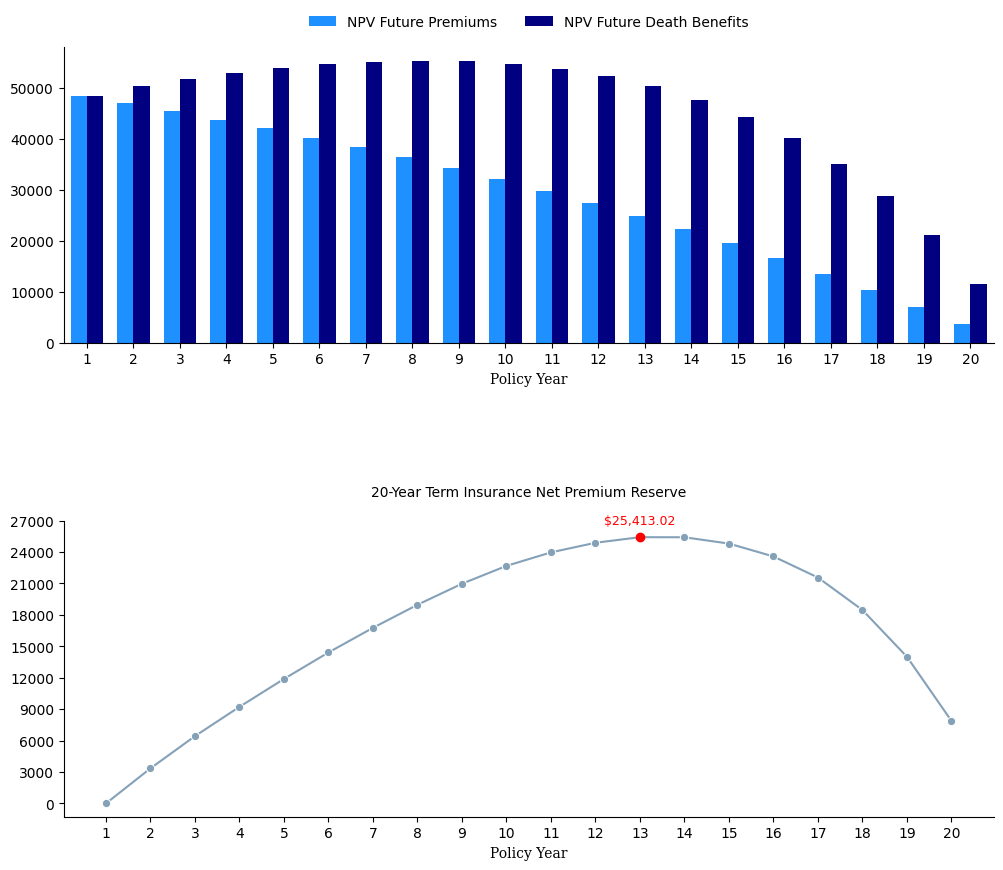

In [194]:
## Plot the term reserves, NPV of future premiums, and NPV of future benefits over the term duration

fig_res = plot_term_reserves(
        reserve_values=reserves,
        prem_npv=premium_npv,
        bene_npv=benefit_npv,
        term_duration=policy.term_duration,
    )



## Visualizations

* **Gender Premium Comparison**

    * Premium comparison charts show that female insureds consistently have lower premiums than male insureds across all risk classes.
    * Premiums increase with issue age for both genders due to increasing mortality risk.
    * The premium differential between males and females is relatively small at middle ages, reaching its lowest point around the mid-30s.
    * Beginning around age 40, the premium gap widens as mortality differences between males and females become more pronounced, resulting in higher relative premiums for males.

* **Risk Class Premium Analysis**

    * The risk class charts display the calculated pure premiums across various issue ages for the three underwriting classes:
        * Super Preferred
        * Preferred
        * Standard
    * Premiums are ordered as expected by underwriting risk, with Super Preferred policies having the lowest premiums and Standard policies having the highest premiums.
    * Across all risk classes, premiums generally increase with issue age, reflecting the higher mortality risk associated with older insureds.
    * The highest premiums are observed among Standard risks at the oldest issue ages.

In [195]:
comparison_df = build_comparison_dataframe(
        pricing_service=pricing_service,
        assumptions=assumptions,
        face_amount=face_amount,
        term_duration=policy.term_duration,
    )

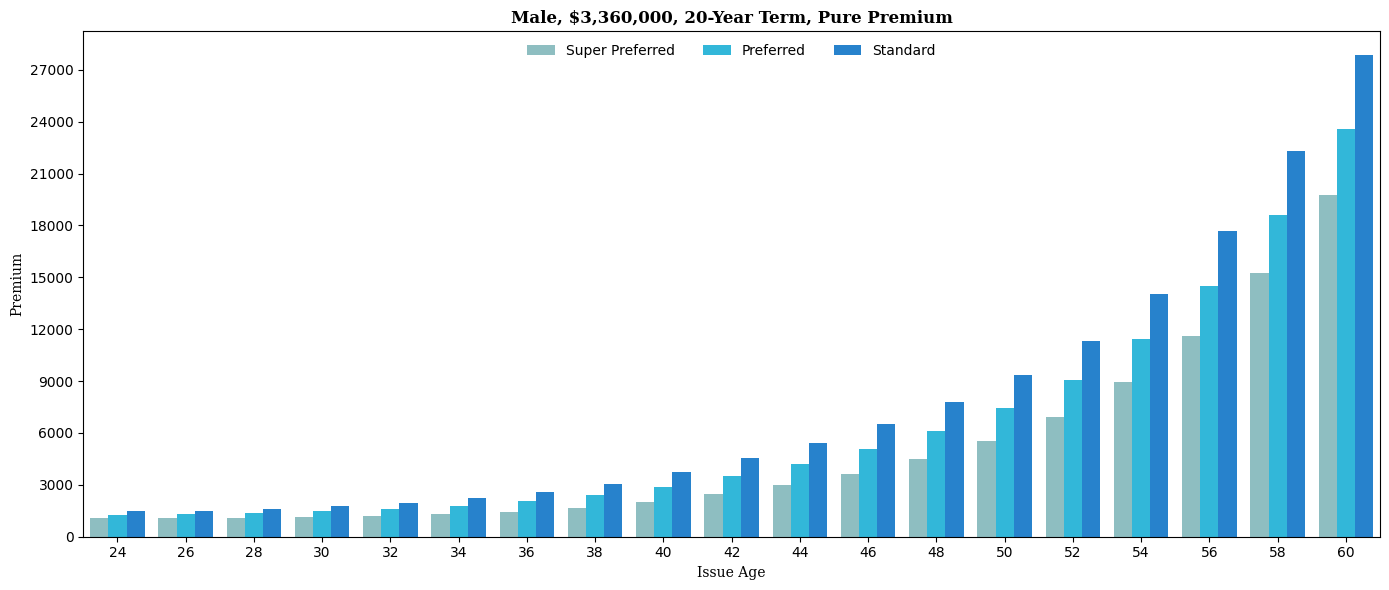

In [196]:
## Plot the gender-specific premiums for males at different ages and risk classes

fig_male =plot_gender_premiums(
    comparison_df,
    "male",
    face_amount,
)

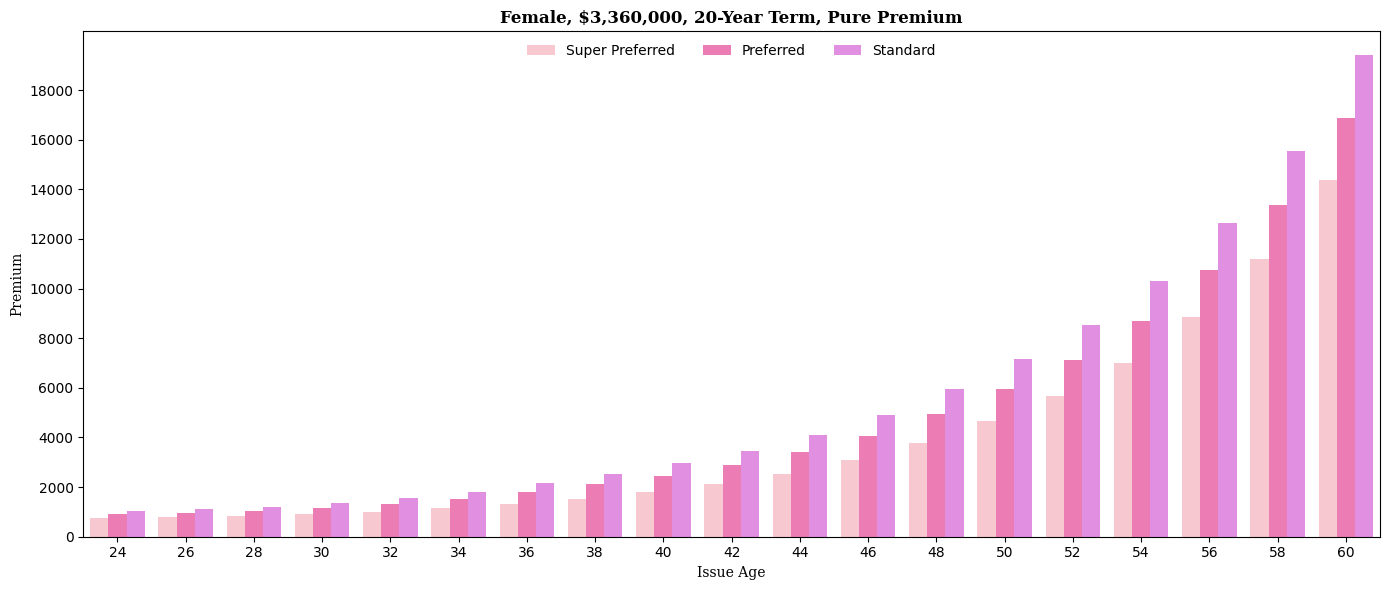

In [197]:
## Plot the gender-specific premiums for females at different ages and risk classes

fig_female = plot_gender_premiums(
        comparison_df,
        "female",
        face_amount,
    )

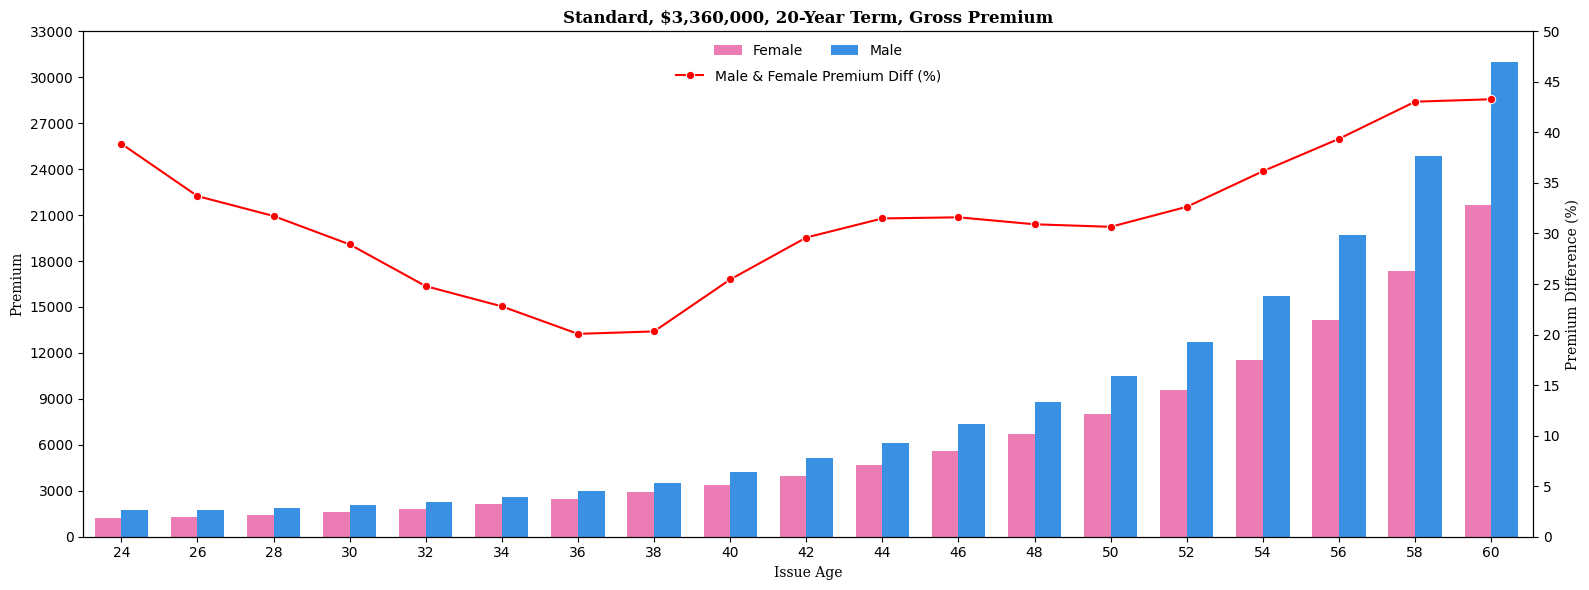

In [198]:
## Plot gross premiums for the Standard risk class across a range of issue ages for the selected term duration.

fig_std =plot_riskclass_premiums(
        comparison_df,
        "standard",
        face_amount,
        gross_prem=True,
        percent_diff= True
    )

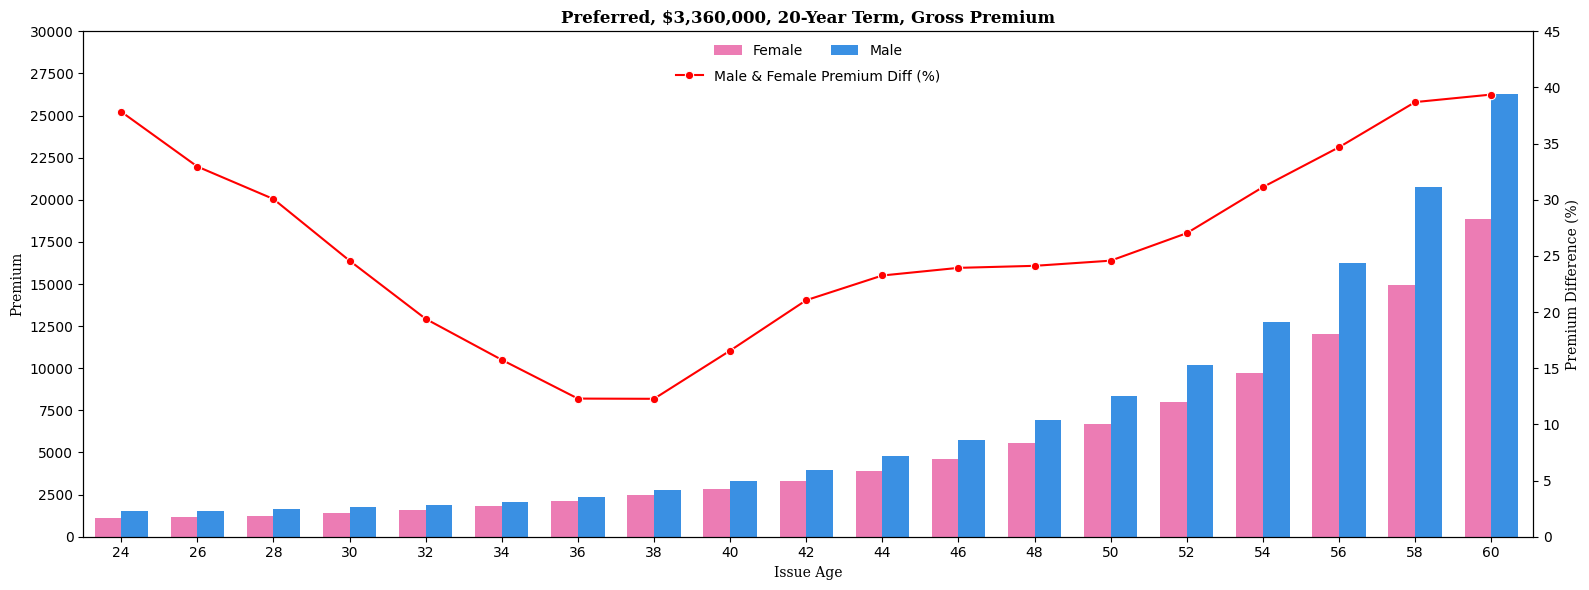

In [199]:
## Plot gross premiums for the Preferred risk class across a range of issue ages for the selected term duration.

fig_pref = plot_riskclass_premiums(
            comparison_df,
            "preferred",
            face_amount,
            gross_prem=True,
            percent_diff= True
        )

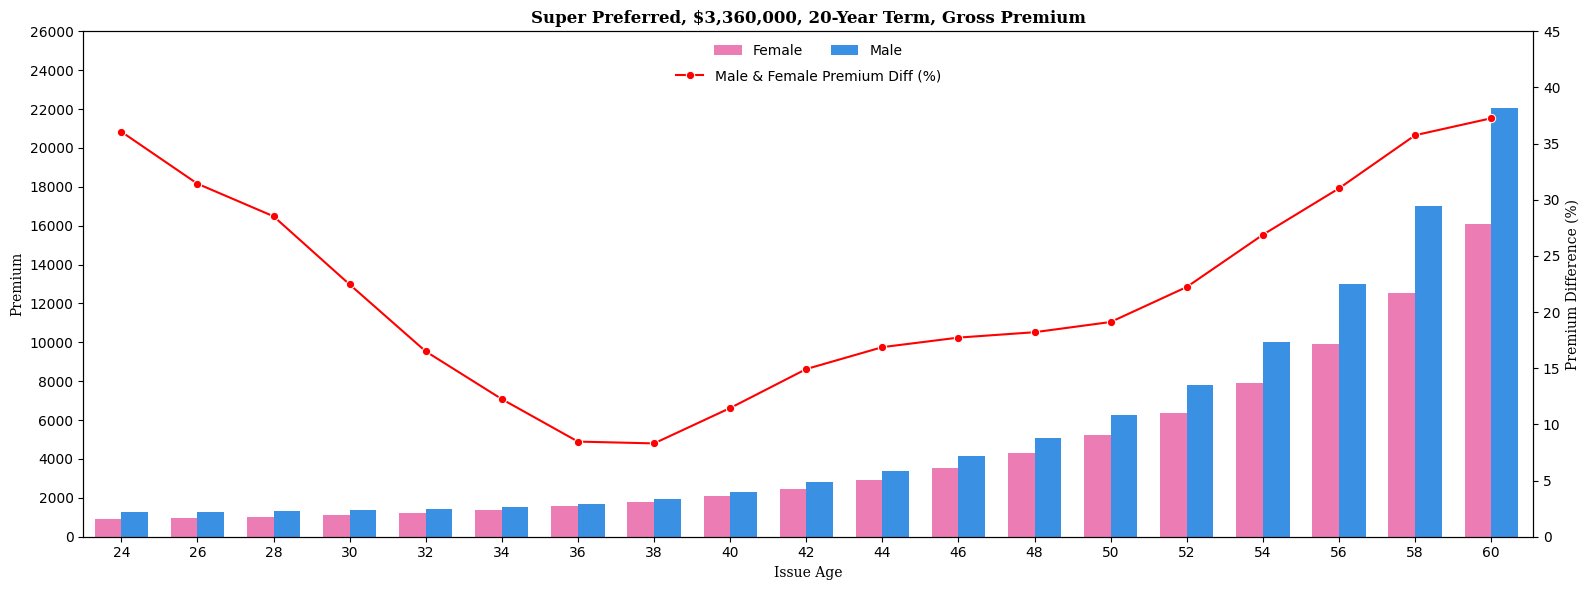

In [200]:
## Plot gross premiums for the Super Preferred risk class across a range of issue ages for the selected term duration.

fig_sup = plot_riskclass_premiums(
            comparison_df,
            "superpreferred",
            face_amount,
            gross_prem=True,
            percent_diff= True
        )